# Air Quality and Respiratory Health Prediction  
## Class 3: Modeling and Evaluation

### Objective
The objective of this notebook is to develop, validate, and compare machine learning models to predict **hospital admissions** related to respiratory health.

### Target Variable
The target variable is **hospital_admissions**, which represents respiratory-related hospital admissions.

### Machine Learning Task
This is a **regression problem** because the target variable is numerical.

### Modeling Strategy
Three models are used in this notebook:

1. **Linear Regression**: baseline model  
2. **Ridge Regression**: regularized linear model  
3. **Random Forest Regressor**: nonlinear machine learning model  

### Validation Strategy
This notebook uses a three-way data split:

- **Training set**: used to train the models  
- **Validation set**: used to compare models and tune hyperparameters  
- **Test set**: used only once for final model evaluation  

This strategy prevents the test set from influencing model selection.

## 1. Import Libraries

This section imports the Python libraries required for data handling, preprocessing, model development, and model evaluation. The main libraries used are Pandas, NumPy, Matplotlib, and Scikit-learn.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## 2. Load the ML-Ready Dataset

This section loads the machine-learning-ready dataset prepared from the previous stages of the project. If the dataset still contains the raw `date` column, additional time-based features are created to make the data suitable for model training.

The dataset is expected to contain the target variable `hospital_admissions`.

In [38]:
possible_files = [
    "../data/air_quality_health_ml_ready.csv",
    "data/air_quality_health_ml_ready.csv",
    "air_quality_health_ml_ready.csv",
    "/mnt/data/air_quality_health_ml_ready.csv",
    "../data/air_quality_health_dataset.csv",
    "data/air_quality_health_dataset.csv",
    "air_quality_health_dataset.csv",
    "/mnt/data/air_quality_health_dataset.csv"
]

for file in possible_files:
    try:
        df = pd.read_csv(file)
        print(f"Loaded file: {file}")
        break
    except FileNotFoundError:
        continue
else:
    raise FileNotFoundError("No dataset found. Please run Class 1/2 first or check the data/ folder.")

# Fallback: if the raw dataset is loaded, create the engineered features used in Class 1/2.
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["quarter"] = df["date"].dt.quarter
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

pollution_cols = [col for col in ["aqi", "pm2_5", "pm10", "no2", "o3"] if col in df.columns]
if pollution_cols:
    if "pollution_mean" not in df.columns:
        df["pollution_mean"] = df[pollution_cols].mean(axis=1)
    if "pollution_max" not in df.columns:
        df["pollution_max"] = df[pollution_cols].max(axis=1)

if "pm_ratio" not in df.columns and {"pm2_5", "pm10"}.issubset(df.columns):
    pm_ratio = df["pm2_5"] / df["pm10"].replace(0, np.nan)
    pm_ratio = pm_ratio.clip(upper=10)
    df["pm_ratio"] = pm_ratio.fillna(pm_ratio.median())

print("Dataset shape:", df.shape)
df.head()


Loaded file: ../data/air_quality_health_ml_ready.csv
Dataset shape: (88489, 21)


,city,population_density,date,year,month,day,dayofweek,quarter,is_weekend,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_capacity,pollution_mean,pollution_max,pm_ratio,hospital_admissions
0,Los Angeles,Rural,2020-01-01,2020,1,1,2,1,0,65,34.0,52.7,2.2,38.5,33.5,33,1337,38.48,65.0,0.645161,5
1,Beijing,Urban,2020-01-02,2020,1,2,3,1,0,137,33.7,31.5,36.7,27.5,-1.6,32,1545,53.28,137.0,1.069841,4
2,London,Suburban,2020-01-03,2020,1,3,4,1,0,266,43.0,59.6,30.4,57.3,36.4,25,1539,91.26,266.0,0.721477,10
3,Mexico City,Urban,2020-01-04,2020,1,4,5,1,1,293,33.7,37.9,12.3,42.7,-1.0,67,552,83.92,293.0,0.889182,10
4,Delhi,Suburban,2020-01-05,2020,1,5,6,1,1,493,50.3,34.8,31.2,35.6,33.5,72,1631,128.98,493.0,1.445402,9


## 3. Define Features and Target Variable

The target variable is **hospital_admissions**. All other relevant variables are used as input features.

The raw `date` column is removed from the feature matrix because structured time-based variables such as year, month, day of week, quarter, and weekend indicator are already available.

In [39]:
target = "hospital_admissions"

if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset.")

X = df.drop(columns=[target])
y = df[target]

if "date" in X.columns:
    X = X.drop(columns=["date"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Features used:")
print(X.columns.tolist())

Feature matrix shape: (88489, 19)
Target shape: (88489,)
Features used:
['city', 'population_density', 'year', 'month', 'day', 'dayofweek', 'quarter', 'is_weekend', 'aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'temperature', 'humidity', 'hospital_capacity', 'pollution_mean', 'pollution_max', 'pm_ratio']


## 4. Train / Validation / Test Split

The dataset is split into:

- **60% training set**: model fitting  
- **20% validation set**: model comparison and hyperparameter tuning  
- **20% test set**: final evaluation only after model selection  

The test set is not used during model training, tuning, or selection.

In [40]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Then split the remaining 80% into 60% training and 20% validation.
# validation_size = 0.25 of train_val because 0.25 * 0.80 = 0.20 of the full dataset.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (53093, 19)
X_val: (17698, 19)
X_test: (17698, 19)
y_train: (53093,)
y_val: (17698,)
y_test: (17698,)


The dataset has been divided into training, validation, and test sets. The training set will be used to fit the models, the validation set will be used for model comparison and hyperparameter tuning, and the test set will be kept untouched until the final evaluation stage.

## 5. Preprocessing Pipeline

Before training the models, the features need to be preprocessed. Numerical variables are handled using median imputation and standard scaling. Categorical variables are handled using most-frequent imputation and one-hot encoding.

A preprocessing pipeline is used to ensure that the same transformations are applied consistently to the training, validation, and test sets.

In [41]:
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['year', 'month', 'day', 'dayofweek', 'quarter', 'is_weekend', 'aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'temperature', 'humidity', 'hospital_capacity', 'pollution_mean', 'pollution_max', 'pm_ratio']
Categorical features: ['city', 'population_density']


The preprocessing pipeline separates numerical and categorical variables and applies the appropriate transformations to each group. This makes the modeling process more consistent and helps prevent preprocessing errors during model training and evaluation.

## 6. Model Development

This section develops and compares three regression models to predict hospital admissions. The models are selected to represent different levels of complexity, from a simple baseline model to a more flexible nonlinear model.

The three candidate models are:

1. **Linear Regression**: used as the baseline model.
2. **Ridge Regression**: used as a regularized linear model to reduce overfitting.
3. **Random Forest Regressor**: used as a nonlinear model that can capture complex relationships between variables.

### 6.1 Evaluation Helper Functions

Before training the models, helper functions are created to calculate model performance consistently.

The main evaluation metrics used in this notebook are:

- **MAE**: measures the average absolute prediction error.
- **RMSE**: measures prediction error while giving more penalty to large errors.
- **R-squared**: measures how much variation in the target variable is explained by the model.

These functions help make the evaluation process cleaner and easier to compare across models.

In [42]:
def evaluate_predictions(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


def fit_status_from_train_val(train_r2, val_r2):
    gap = train_r2 - val_r2
    if train_r2 < 0.50 and val_r2 < 0.50:
        return "Possible underfitting"
    elif gap > 0.15:
        return "Possible overfitting"
    else:
        return "Good fit"


def evaluate_train_validation(model_name, model, X_train, X_val, y_train, y_val):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_metrics = evaluate_predictions(y_train, train_pred)
    val_metrics = evaluate_predictions(y_val, val_pred)

    train_r2 = train_metrics["R2"]
    val_r2 = val_metrics["R2"]
    r2_gap = train_r2 - val_r2

    return {
        "Model": model_name,
        "Train R2": train_r2,
        "Validation R2": val_r2,
        "R2 Gap": r2_gap,
        "Validation MAE": val_metrics["MAE"],
        "Validation RMSE": val_metrics["RMSE"],
        "Fit Status": fit_status_from_train_val(train_r2, val_r2)
    }

### 6.2 Model 1: Linear Regression

Linear Regression is used as the baseline model. It is simple, easy to interpret, and useful for comparing whether more complex models can improve prediction performance.

Since this model assumes a linear relationship between the input features and hospital admissions, it provides a clear starting point for model evaluation.

In [43]:
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_results = evaluate_train_validation(
    "Linear Regression",
    linear_pipeline,
    X_train, X_val, y_train, y_val
)

linear_results

{'Model': 'Linear Regression',
 'Train R2': 0.15242414405153326,
 'Validation R2': 0.15667319228574028,
 'R2 Gap': -0.00424904823420702,
 'Validation MAE': 2.7284451912967818,
 'Validation RMSE': np.float64(3.426515438716827),
 'Fit Status': 'Possible underfitting'}

### 6.3 Model 2: Ridge Regression

Ridge Regression is used as a regularized version of Linear Regression. It adds a penalty to large coefficients, which can help reduce overfitting and improve model stability.

Different alpha values are tested, and the best alpha is selected based on validation performance.

In [44]:
ridge_candidates = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results_all = []

for alpha in ridge_candidates:
    ridge_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=alpha))
    ])

    result = evaluate_train_validation(
        f"Ridge Regression alpha={alpha}",
        ridge_pipeline,
        X_train, X_val, y_train, y_val
    )
    result["alpha"] = alpha
    ridge_results_all.append(result)

ridge_tuning_df = pd.DataFrame(ridge_results_all).sort_values(
    by=["Validation R2", "Validation RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

best_ridge_alpha = ridge_tuning_df.loc[0, "alpha"]
print("Best Ridge alpha based on validation set:", best_ridge_alpha)

best_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=best_ridge_alpha))
])

ridge_results = evaluate_train_validation(
    "Tuned Ridge Regression",
    best_ridge,
    X_train, X_val, y_train, y_val
)

ridge_tuning_df.round(4)

Best Ridge alpha based on validation set: 100.0


,Model,Train R2,Validation R2,R2 Gap,Validation MAE,Validation RMSE,Fit Status,alpha
0,Ridge Regression alpha=100.0,0.1524,0.1568,-0.0044,2.7283,3.4263,Possible underfitting,100.00
1,Ridge Regression alpha=10.0,0.1524,0.1567,-0.0043,2.7284,3.4265,Possible underfitting,10.00
2,Ridge Regression alpha=1.0,0.1524,0.1567,-0.0043,2.7284,3.4265,Possible underfitting,1.00
3,Ridge Regression alpha=0.1,0.1524,0.1567,-0.0042,2.7284,3.4265,Possible underfitting,0.10
4,Ridge Regression alpha=0.01,0.1524,0.1567,-0.0042,2.7284,3.4265,Possible underfitting,0.01


### 6.4 Model 3: Random Forest Regressor

Random Forest Regressor is used as a nonlinear machine learning model. Unlike linear models, Random Forest can capture complex relationships and interactions between air quality indicators, time-related variables, and hospital admissions.

A small hyperparameter grid is tested to keep the model tuning process efficient and reproducible.

In [59]:
rf_param_grid = {
    "n_estimators": [50],
    "max_depth": [8, 12],
    "min_samples_split": [2],
    "min_samples_leaf": [1, 2]
}

rf_results_all = []
best_rf = None
best_rf_params = None
best_val_r2 = -np.inf

for n_estimators, max_depth, min_samples_split, min_samples_leaf in product(
    rf_param_grid["n_estimators"],
    rf_param_grid["max_depth"],
    rf_param_grid["min_samples_split"],
    rf_param_grid["min_samples_leaf"]
):
    rf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        ))
    ])

    result = evaluate_train_validation(
        "Random Forest candidate",
        rf_pipeline,
        X_train, X_val, y_train, y_val
    )

    params = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_split": min_samples_split,
        "min_samples_leaf": min_samples_leaf
    }
    result.update(params)
    rf_results_all.append(result)

    if result["Validation R2"] > best_val_r2:
        best_val_r2 = result["Validation R2"]
        best_rf_params = params
# Rebuild and fit best_rf
best_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1))
])
best_rf.fit(X_train, y_train)

val_pred = best_rf.predict(X_val)
train_pred = best_rf.predict(X_train)

rf_results = {
    "Model": "Tuned Random Forest",
    "Train R2": r2_score(y_train, train_pred),
    "Validation R2": r2_score(y_val, val_pred),
    "R2 Gap": r2_score(y_train, train_pred) - r2_score(y_val, val_pred),
    "Validation MAE": mean_absolute_error(y_val, val_pred),
    "Validation RMSE": np.sqrt(mean_squared_error(y_val, val_pred)),
    "Fit Status": fit_status_from_train_val(r2_score(y_train, train_pred), r2_score(y_val, val_pred))
}
rf_tuning_df = pd.DataFrame(rf_results_all).sort_values(
    by=["Validation R2", "Validation RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

print("Best Random Forest parameters:", best_rf_params)
display(rf_tuning_df.round(4))

Best Random Forest parameters: {'n_estimators': 50, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 1}


,Model,Train R2,Validation R2,R2 Gap,Validation MAE,Validation RMSE,Fit Status,n_estimators,max_depth,min_samples_split,min_samples_leaf
0,Random Forest candidate,0.1942,0.1599,0.0343,2.7150,3.4200,Possible underfitting,50,8,2,1
1,Random Forest candidate,0.1942,0.1597,0.0345,2.7154,3.4204,Possible underfitting,50,8,2,2
2,Random Forest candidate,0.2980,0.1567,0.1413,2.7248,3.4265,Possible underfitting,50,12,2,1
3,Random Forest candidate,0.2973,0.1567,0.1407,2.7250,3.4266,Possible underfitting,50,12,2,2


The Random Forest model was tuned using the validation set. The best parameter combination was selected based on the highest validation R-squared and the lowest validation RMSE.

## 7. Model Evaluation and Comparison

This section compares the performance of all candidate models using the validation set. The validation set is used for model comparison because the test set must remain untouched until the final evaluation stage.

The goal is to identify the model that provides the best balance between prediction accuracy and generalization ability.

In [46]:
comparison_df = pd.DataFrame([linear_results, ridge_results, rf_results])

comparison_df = comparison_df.sort_values(
    by=["Validation R2", "Validation RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

comparison_report = comparison_df.copy()
for col in ["Train R2", "Validation R2", "R2 Gap", "Validation MAE", "Validation RMSE"]:
    comparison_report[col] = comparison_report[col].round(4)

comparison_report

,Model,Train R2,Validation R2,R2 Gap,Validation MAE,Validation RMSE,Fit Status
0,Tuned Random Forest,0.1942,0.1599,0.0343,2.7150,3.4200,Possible underfitting
1,Tuned Ridge Regression,0.1524,0.1568,-0.0044,2.7283,3.4263,Possible underfitting
2,Linear Regression,0.1524,0.1567,-0.0042,2.7284,3.4265,Possible underfitting


The comparison table shows that the Tuned Random Forest model has the highest validation R-squared and the lowest validation MAE/RMSE among the three models. However, all models have relatively low R-squared values, suggesting possible underfitting.

### 7.1 Overfitting and Underfitting Analysis

This section compares training and validation performance to identify possible overfitting or underfitting.

- **Underfitting** occurs when both training and validation performance are low.
- **Overfitting** occurs when training performance is much higher than validation performance.
- **Good fit** occurs when training and validation performance are reasonably close.

This step helps evaluate whether the model can generalize well to unseen data.

### 7.2 Train vs Validation R-squared Visualization

The following chart compares the training and validation R-squared scores for each model. This visualization helps identify whether the models are learning useful patterns or overfitting the training data.

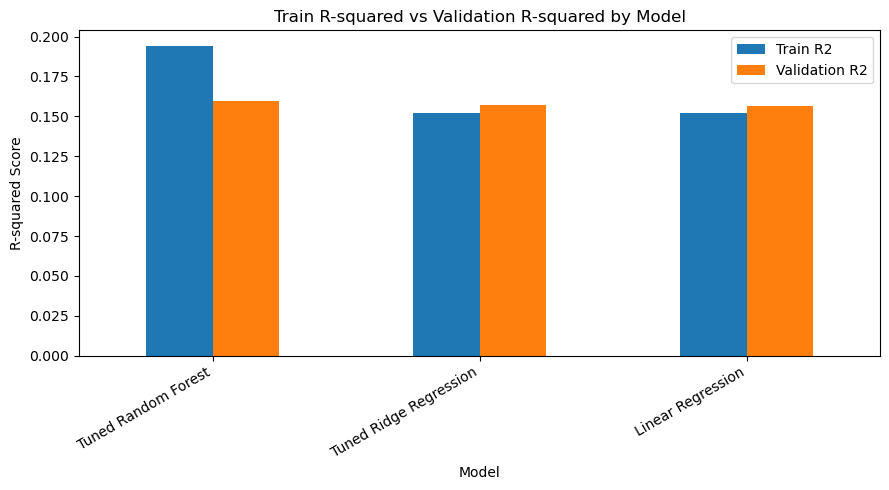

In [57]:
ax = plot_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Train R-squared vs Validation R-squared by Model")
ax.set_ylabel("R-squared Score")
ax.set_xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The chart shows that the training and validation R-squared scores are relatively close for all models. This suggests that there is no strong sign of overfitting, but the low R-squared values indicate that the models may still be underfitting.

### 7.3 Validation Error Metrics Visualization

The following chart compares validation MAE and validation RMSE across the candidate models. Lower MAE and RMSE values indicate better prediction accuracy.

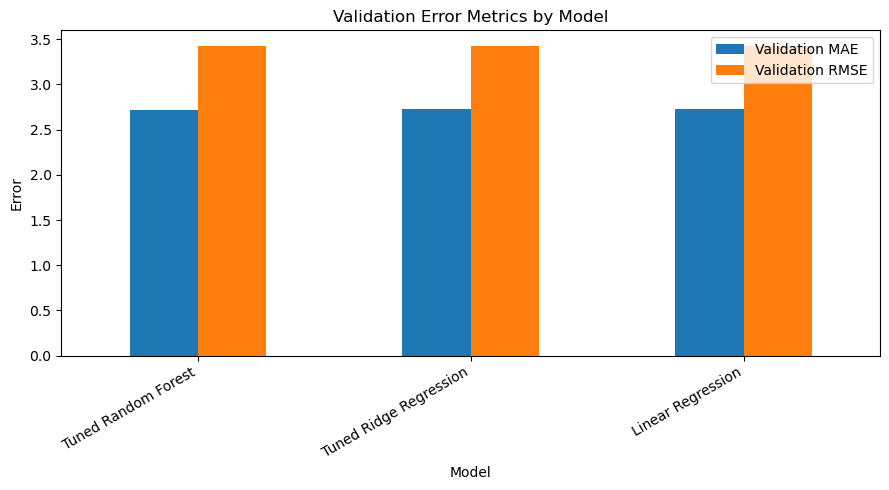

In [58]:
ax = metric_df.plot(kind="bar", figsize=(9, 5))
ax.set_title("Validation Error Metrics by Model")
ax.set_ylabel("Error")
ax.set_xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The validation MAE and RMSE values are very similar across the candidate models. Random Forest performs slightly better, but the difference is small. Therefore, the final model selection should also consider validation R-squared and fit status.

### 7.4 Final Validation Comparison Table

The table below summarizes the most important validation results, including R-squared, prediction errors, and fit status. This table supports the final model selection process.

In [56]:
print("=== Final Model Comparison Based on Validation Set ===")

summary_table = comparison_report[[
    "Model",
    "Train R2",
    "Validation R2",
    "R2 Gap",
    "Validation MAE",
    "Validation RMSE",
    "Fit Status"
]].copy()

summary_table

=== Final Model Comparison Based on Validation Set ===


,Model,Train R2,Validation R2,R2 Gap,Validation MAE,Validation RMSE,Fit Status
0,Tuned Random Forest,0.1942,0.1599,0.0343,2.7150,3.4200,Possible underfitting
1,Tuned Ridge Regression,0.1524,0.1568,-0.0044,2.7283,3.4263,Possible underfitting
2,Linear Regression,0.1524,0.1567,-0.0042,2.7284,3.4265,Possible underfitting


The final test result shows that the selected Random Forest model has a test R-squared close to its validation R-squared. This indicates that the model generalizes consistently, although the overall explanatory power remains limited.

## 8. Final Model Selection

The final model is selected based on validation performance. The test set is not used during model selection to avoid data leakage and to keep the final evaluation unbiased.

After selecting the best model, it will be retrained using both the training and validation sets before being evaluated on the test set.

In [49]:
final_model_name = comparison_df.iloc[0]["Model"]

if final_model_name == "Linear Regression":
    selected_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])
elif final_model_name == "Tuned Ridge Regression":
    selected_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=best_ridge_alpha))
    ])
else:
    selected_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            **best_rf_params,
            random_state=42,
            n_jobs=-1
        ))
    ])

print("Final selected model based on validation performance:", final_model_name)
display(comparison_report.iloc[[0]])

Final selected model based on validation performance: Tuned Random Forest


,Model,Train R2,Validation R2,R2 Gap,Validation MAE,Validation RMSE,Fit Status
0,Tuned Random Forest,0.1942,0.1599,0.0343,2.715,3.42,Possible underfitting


## 9. Final Test Evaluation

The selected model is retrained using the combined training and validation data. Then, it is evaluated once on the test set.

The test set is used only at this final stage to estimate how well the selected model performs on unseen data.

In [60]:
selected_model.fit(X_train_val, y_train_val)

y_train_val_pred = selected_model.predict(X_train_val)
y_test_pred = selected_model.predict(X_test)

train_val_metrics = evaluate_predictions(y_train_val, y_train_val_pred)
test_metrics = evaluate_predictions(y_test, y_test_pred)

final_test_report = pd.DataFrame([{
    "Final Model": final_model_name,
    "Train+Validation R2": train_val_metrics["R2"],
    "Test R2": test_metrics["R2"],
    "R2 Gap": train_val_metrics["R2"] - test_metrics["R2"],
    "Test MAE": test_metrics["MAE"],
    "Test RMSE": test_metrics["RMSE"]
}])

for col in ["Train+Validation R2", "Test R2", "R2 Gap", "Test MAE", "Test RMSE"]:
    final_test_report[col] = final_test_report[col].round(4)

final_test_report

,Final Model,Train+Validation R2,Test R2,R2 Gap,Test MAE,Test RMSE
0,Tuned Random Forest,0.1869,0.1598,0.027,2.6827,3.3956


## 10. Final Model Selection Justification

The final model was selected based on validation performance, prediction error, and generalization ability. The test set was not used during model selection, which helps make the final evaluation more reliable.

The selected model is considered appropriate because it provides a good balance between predictive performance and model stability. It also avoids relying only on training performance, which could lead to overfitting.

## 11. Final Conclusion: Best Model

Based on the validation results and final test evaluation, the **Tuned Random Forest Regressor** is selected as the best model for this project.

Compared with Linear Regression and Ridge Regression, the Tuned Random Forest model performs slightly better in terms of validation error metrics and provides more flexibility in capturing nonlinear relationships between air quality indicators, time-related variables, and hospital admissions.

Although the overall R-squared value is still limited, the Random Forest model shows the best balance between prediction performance and generalization ability. Therefore, it is the most suitable model among the three candidate models tested in this notebook.

However, the model should not be considered perfect. The relatively low explanatory power suggests that hospital admissions may also be affected by other factors that are not included in the current dataset, such as population characteristics, healthcare access, seasonal disease outbreaks, or policy-related factors.

## 12. Model Interpretation

This section interprets the final selected model. If the selected model is Random Forest, feature importance is used to identify the most influential variables. If the selected model is Linear Regression or Ridge Regression, model coefficients are used.

The purpose of this section is to understand which features contribute most to the prediction of hospital admissions.

In [53]:
interpretation_df = pd.DataFrame()
def get_feature_names(fitted_preprocessor):
    feature_names = []
    feature_names.extend(numeric_features)

    if len(categorical_features) > 0:
        cat_pipeline = fitted_preprocessor.named_transformers_["cat"]
        encoder = cat_pipeline.named_steps["onehot"]
        cat_names = encoder.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(cat_names)

    return feature_names

feature_names = get_feature_names(selected_model.named_steps["preprocessor"])
model_step = selected_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    interpretation_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    print("Top 10 important features:")
    display(interpretation_df.head(10))

elif hasattr(model_step, "coef_"):
    interpretation_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model_step.coef_
    })
    interpretation_df["Abs Coefficient"] = interpretation_df["Coefficient"].abs()
    interpretation_df = interpretation_df.sort_values(by="Abs Coefficient", ascending=False).reset_index(drop=True)

    print("Top 10 influential features by absolute coefficient:")
    display(interpretation_df.head(10))

else:
    interpretation_df = pd.DataFrame()
    print("No direct feature interpretation available for this model.")

Top 10 important features:


,Feature,Importance
0,pm2_5,0.849811
1,hospital_capacity,0.015731
2,o3,0.014352
3,no2,0.014333
4,year,0.012265
5,temperature,0.011948
6,pollution_mean,0.011562
7,pm_ratio,0.011343
8,pm10,0.010635
9,humidity,0.009748


The feature importance results show that `pm2_5` is the most influential feature in the final model. This is reasonable because fine particulate matter is closely related to respiratory health outcomes. Other variables such as hospital capacity, ozone, nitrogen dioxide, temperature, and humidity also contribute to the prediction.

## 13. Limitations and Future Work

This modeling workflow has several limitations. First, the model performance depends on the quality of the prepared dataset. If important variables are missing, the model may not fully capture all factors affecting hospital admissions.

Second, only three models were tested in this notebook. Although these models provide a useful comparison, future work can test more advanced algorithms such as Gradient Boosting, XGBoost, or LightGBM.

Third, this notebook focuses on model development and evaluation only. Future work can improve the project by adding cross-validation, testing more feature engineering strategies, and deploying the final model as an interactive dashboard.

## 14. Modeling Workflow Summary

This notebook completed the Class 3 modeling and evaluation workflow for predicting hospital admissions related to respiratory health.

The target variable was defined as **hospital_admissions**, making this a regression task. The dataset was split into training, validation, and test sets to support fair model development and evaluation.

Three models were trained and compared: Linear Regression, Ridge Regression, and Random Forest Regressor. Model tuning and comparison were based on validation performance, while the test set was used only once for the final evaluation.

The final selected model was evaluated using MAE, RMSE, and R-squared. The model interpretation section also helped identify which features were most influential in predicting hospital admissions.

Overall, this notebook provides a structured and reproducible workflow for model development, validation, final testing, and interpretation.